# **4.5 Cutting Planes and Facets**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1JQtvYNpkuGLsc3gtXJqLDD27x9hcadXl?usp=sharing)


There is an extensive literature concerning the use of cutting planes to solve integer programming problems. Early algorithms were theoretically intriguing, but not very effective in practice. However, some recent developments in the application of special cutting planes for problems with specific structure have produced some rather surprising results. One example is presented in Section 4.6 for the pure 0–1 problem. This section briefly discusses the general concepts and provides some background.

&nbsp;&nbsp;&nbsp;&nbsp;Given any integer programming problem, consider the set of feasible integer points. If the extreme points of the LP are all integers, then the problem is easy; the LP solution will be an integer solution. If the extreme points are not integer, then we can always *tighten up* the constraints and possibly add new ones in such a way that the new reduced LP does have integer extreme points.

&nbsp;&nbsp;&nbsp;&nbsp;For an intuitive motivation of this statement, suppose that the LP has an optimal extreme point solution that is not an integer. Then, it should be possible to add a new constraint that makes that extreme point infeasible by at least a small amount without excluding any feasible integer solutions. We will illustrate shortly that this is always possible. We can repeat this process until all extreme points are integers.

&nbsp;&nbsp;&nbsp;&nbsp;The general idea is illustrated in **Figure 4.8**. Given a feasible region defined by the constraints of a linear programming formulation, we are interested in only the integer points inside the region. In the figure, the outside polygon defines the LP feasible region; the inside polygon defines a unique tightened region that does not exclude any integer solutions. We call the reduced region the **convex hull** of the set of feasible integers. It is also referred to as the **integer polytope** of the problem. (A **polytope** is an n-dimensional polygon.)

&nbsp;&nbsp;&nbsp;&nbsp;A constraint is called a **face** or **facet** of the integer polytope if it defines an $(n - 1)$-dimensional set of points on the surface of the convex hull. In the two-dimensional example, a facet is a line of feasible points between two integer extreme solutions. In a three-dimensional cube, for example, the facets are simply the two-dimensional faces of the cube. A constraint that meets the cube along only an edge, one dimension, is not a facet. Clearly, at least in three dimensions, there must be one facet constraint for each face, and no others are needed to define the integer polytope.

&nbsp;&nbsp;&nbsp;&nbsp;If we could find all the facets of an integer problem, then all of the extreme points would be integers and the LP solution method would easily find the optimal integer solution. Unfortunately, for general problems, it is extremely difficult to find the facets of the convex hull. Much of the current research in integer programming is devoted to finding some facet-defining constraints for very specific problems.

<br>

<div align="center">

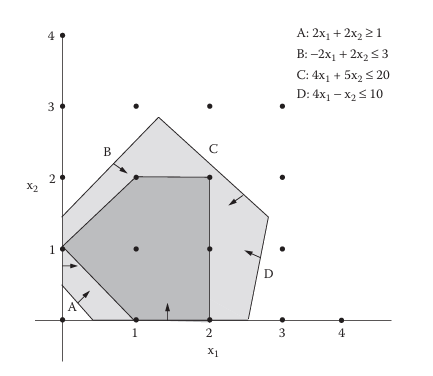

</div>



**Figure 4.8**  
The convex hull of the set of integer solutions.

<br>

&nbsp;&nbsp;&nbsp;&nbsp;The preceding observations have led many researchers to try to develop algorithms that would try to approximate the convex hull of the integer polytope. In particular, it is not necessary to find all of the facets, only the ones that define the integer optimum. Consider the following general algorithm:

1. Solve the LP.

2. If the solution is integer, then it must be optimal.

3. Otherwise, generate a **cutting plane** that excludes the current LP solution, but does not exclude any integer points, and then return to Step 1.

By our definition, a cutting plane is not necessarily a facet. A cutting plane is only guaranteed to take a slice of non-integer solutions out of the feasible region. In general, facets are hard to find, while cutting planes are easy; but, of course, the best cutting plane would be a facet.

&nbsp;&nbsp;&nbsp;&nbsp;Consider the example problem from Section 4.4.4, the branch-and-bound example after the coefficients have been reduced. The optimal Simplex tableau is:

<br>

<div align="center">

<table style="font-size:18px; border-collapse:collapse; text-align:center;">
  <tr>
    <th style="padding:8px 16px; border-bottom:2px solid black;">Basis</th>
    <th style="padding:8px 16px; border-bottom:2px solid black;">$x_1$</th>
    <th style="padding:8px 16px; border-bottom:2px solid black;">$x_2$</th>
    <th style="padding:8px 16px; border-bottom:2px solid black;">$x_3$</th>
    <th style="padding:8px 16px; border-bottom:2px solid black;">$x_4$</th>
    <th style="padding:8px 16px; border-bottom:2px solid black;">Solution</th>
  </tr>
  <tr>
    <td style="padding:8px 16px;">$z$</td>
    <td style="padding:8px 16px;">0</td>
    <td style="padding:8px 16px;">0</td>
    <td style="padding:8px 16px;">$\frac{7}{19}$</td>
    <td style="padding:8px 16px;">$\frac{3}{19}$</td>
    <td style="padding:8px 16px;">$13\frac{7}{19}$</td>
  </tr>
  <tr>
    <td style="padding:8px 16px;">$x_1$</td>
    <td style="padding:8px 16px;">1</td>
    <td style="padding:8px 16px;">0</td>
    <td style="padding:8px 16px;">$\frac{4}{57}$</td>
    <td style="padding:8px 16px;">$-\frac{1}{57}$</td>
    <td style="padding:8px 16px;">$1\frac{15}{19}$</td>
  </tr>
  <tr>
    <td style="padding:8px 16px; border-bottom:2px solid black;">$x_2$</td>
    <td style="padding:8px 16px; border-bottom:2px solid black;">0</td>
    <td style="padding:8px 16px; border-bottom:2px solid black;">1</td>
    <td style="padding:8px 16px; border-bottom:2px solid black;">$-\frac{1}{19}$</td>
    <td style="padding:8px 16px; border-bottom:2px solid black;">$\frac{5}{19}$</td>
    <td style="padding:8px 16px; border-bottom:2px solid black;">$3\frac{3}{19}$</td>
  </tr>
</table>

</div>

<br>

As a simple example of a cutting plane, observe that one row of the tableau can be written as:

<br>

$$
x_1 + \frac{4}{57}x_3 - \frac{1}{57}x_4 = 1\frac{15}{19}
$$

<br>

Every feasible solution to this problem must satisfy this constraint, which is derived by elementary row operations on the original constraints. To obtain an integer solution for $x_1$, at least one of the non-basic variables will have to increase, and these must also be integer. This leads to the simple cutting plane:

$$
x_3 + x_4 \geq 1
$$

<br>

At the current LP optimum, $x_3$ and $x_4$ are both equal to zero. Therefore, this constraint must make the current point infeasible. Furthermore, every feasible integer solution must satisfy this constraint, so no integers have been excluded. That is, this constraint satisfies the criteria for a cutting plane.

&nbsp;&nbsp;&nbsp;&nbsp;Notice that there is no branching involved here; at each iteration, we define a smaller feasible region, solve the new LP, and repeat the process, continuing until all of the basic variables are integers.

&nbsp;&nbsp;&nbsp;&nbsp;This procedure looks intuitively appealing because the cuts are easy to find and there are none of the complicated storage and bound problems associated with branch-and-bound methods. However, it is not a very efficient or effective technique. As an exercise, the reader should try a few iterations on the example problem. Convergence is generally very slow, which means that we have to generate a large number of new constraints. In fact, for this particular cut, we cannot even prove that the procedure is always finite.

&nbsp;&nbsp;&nbsp;&nbsp;A wide variety of better cutting planes have been proposed, of which the best known is called a **Gomory fractional cut**. This method is based on the premise that, in any integer solution, all of the fractional parts in the tableau must cancel one another. Consider the previous example for $x_1$. From the tableau:

<br>

$$
x_1 + \frac{4}{57}x_3 - \frac{1}{57}x_4 = 1\frac{15}{19}
$$

<br>

We first separate each coefficient into two parts: an integer component and a *positive fractional* part:

<br>

$$
x_1 + 0x_3 + \frac{4}{57}x_3 - x_4 + \frac{56}{57}x_4 = 1 + \frac{15}{19}
$$

<br>

Grouping all of the *integer* parts together on the right-hand side, we obtain:

<br>

$$
\frac{4}{57}x_3 + \frac{56}{57}x_4 = [-x_1 + x_4 + 1] + \frac{15}{19}
$$

<br>

Observe that, for any integer solution, the part in square brackets must also be integer. Moreover, because the variables must be non-negative, the left-hand side must be positive. In fact, the left-hand side must be equal to $15/19$ or $1\frac{15}{19}$ or $2\frac{15}{19}$ or $3\frac{15}{19}$, and so on. In other words:

<br>

$$
\frac{4}{57}x_3 + \frac{56}{57}x_4 \geq \frac{15}{19}
$$

<br>

This is the Gomory fractional cut. Because the non-basic variables, $x_3$ and $x_4$, are equal to zero at the current LP solution, the Gomory cut always cuts off the corner of the feasible region containing the optimal solution. If any variable has a fractional solution, it is always possible to construct a Gomory cut. This method has the property that it will converge in a finite number of iterations.

&nbsp;&nbsp;&nbsp;&nbsp;The main disadvantages associated with the Gomory fractional cut method are: (1) the method can converge slowly; and (2) unlike branch-and-bound methods, integer solutions are not obtained until the very end. Pure cutting plane methods are therefore not considered to be very practical for large problems.

**Code Implmentation**

In [ ]:
# Install required packages (run once in Colab)
!pip install pyomo --quiet
!apt-get install -y -qq coinor-cbc
!pip install scipy numpy --quiet

In [ ]:
from pyomo.environ import *
import numpy as np

In [ ]:
from pyomo.environ import *

# ── Step 1: LP relaxation ────────────────────────────────────────────────
m_lp = ConcreteModel()
m_lp.x1 = Var(within=NonNegativeReals)
m_lp.x2 = Var(within=NonNegativeReals)
m_lp.obj = Objective(expr=6*m_lp.x1 + m_lp.x2, sense=maximize)
m_lp.c1  = Constraint(expr=15*m_lp.x1 +  m_lp.x2 <= 30)
m_lp.c2  = Constraint(expr= 3*m_lp.x1 + 4*m_lp.x2 <= 18)
SolverFactory('cbc').solve(m_lp)
x1_lp, x2_lp = m_lp.x1.value, m_lp.x2.value

print('=== 4.5 Cutting Planes — Gomory Cut ===')
print(f'\nStep 1 — LP relaxation:')
print(f'  x1 = {x1_lp:.4f}  (= 1 + 15/19 = 1{15/19:.4f})')
print(f'  x2 = {x2_lp:.4f}  (= 3 + 3/19  = 3{3/19:.4f})')
print(f'  z  = {m_lp.obj():.4f}  (= 13 + 7/19)')

# ── Step 2: Gomory cut from the x1 tableau row ───────────────────────────
# Textbook cut: x3 + x4 >= 1  (slacks of c1 and c2)
# x3 = 30 - 15x1 - x2  >=0,  x4 = 18 - 3x1 - 4x2 >= 0
# Cut: (30-15x1-x2) + (18-3x1-4x2) >= 1  → 18x1+5x2 <= 47
print(f'\nStep 2 — Textbook Gomory cut (from x1 tableau row):')
print(f'  Slack variables: x3 = 30-15x1-x2,  x4 = 18-3x1-4x2')
print(f'  Cut: x3 + x4 >= 1  →  18x1 + 5x2 <= 47')
print(f'  At LP optimum: x3=x4=0 → cut is VIOLATED → point is excluded')

# ── Step 3: Add cut and resolve ──────────────────────────────────────────
m_cut = ConcreteModel()
m_cut.x1 = Var(within=NonNegativeReals)
m_cut.x2 = Var(within=NonNegativeReals)
m_cut.obj = Objective(expr=6*m_cut.x1 + m_cut.x2, sense=maximize)
m_cut.c1  = Constraint(expr=15*m_cut.x1 +  m_cut.x2 <= 30)
m_cut.c2  = Constraint(expr= 3*m_cut.x1 + 4*m_cut.x2 <= 18)
m_cut.gomory = Constraint(expr=18*m_cut.x1 + 5*m_cut.x2 <= 47)  # Gomory cut
SolverFactory('cbc').solve(m_cut)
print(f'\nStep 3 — After adding Gomory cut:')
print(f'  x1 = {m_cut.x1.value:.4f},  x2 = {m_cut.x2.value:.4f},  z = {m_cut.obj():.4f}')

# ── Integer optimum ──────────────────────────────────────────────────────
m_ip = ConcreteModel()
m_ip.x1 = Var(within=NonNegativeIntegers)
m_ip.x2 = Var(within=NonNegativeIntegers)
m_ip.obj = Objective(expr=6*m_ip.x1 + m_ip.x2, sense=maximize)
m_ip.c1  = Constraint(expr=15*m_ip.x1 +  m_ip.x2 <= 30)
m_ip.c2  = Constraint(expr= 3*m_ip.x1 + 4*m_ip.x2 <= 18)
SolverFactory('cbc').solve(m_ip)
print(f'\nInteger optimum: x1={int(round(m_ip.x1.value))}, x2={int(round(m_ip.x2.value))}, z={int(round(m_ip.obj()))}')

=== 4.5 Cutting Planes — Gomory Cut ===

Step 1 — LP relaxation:
  x1 = 1.7895  (= 1 + 15/19 = 10.7895)
  x2 = 3.1579  (= 3 + 3/19  = 30.1579)
  z  = 13.8947  (= 13 + 7/19)

Step 2 — Textbook Gomory cut (from x1 tableau row):
  Slack variables: x3 = 30-15x1-x2,  x4 = 18-3x1-4x2
  Cut: x3 + x4 >= 1  →  18x1 + 5x2 <= 47
  At LP optimum: x3=x4=0 → cut is VIOLATED → point is excluded

Step 3 — After adding Gomory cut:
  x1 = 1.8070,  x2 = 2.8947,  z = 13.7368

Integer optimum: x1=2, x2=0, z=12
